# Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA (Exploratory Data Analysis)

In [4]:
print(f"The total number of rows in the DataFrame are: {df.shape[0]}")
print(f"The total number of cols in the DataFrame are: {df.shape[1]}")

The total number of rows in the DataFrame are: 1338
The total number of cols in the DataFrame are: 7


In [5]:
df.info() # Give information about DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe() # Describe the numerical cols

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Finding missing value in the DataFrame

In [7]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data Visualization

In [8]:
print(df.columns, "\n\n")
df.info()

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object') 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
df[numeric_cols]

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


### Plotting Histogram

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sb.histplot(df[col], kde=True, bins=20)

### Count plots


<Axes: xlabel='children', ylabel='count'>

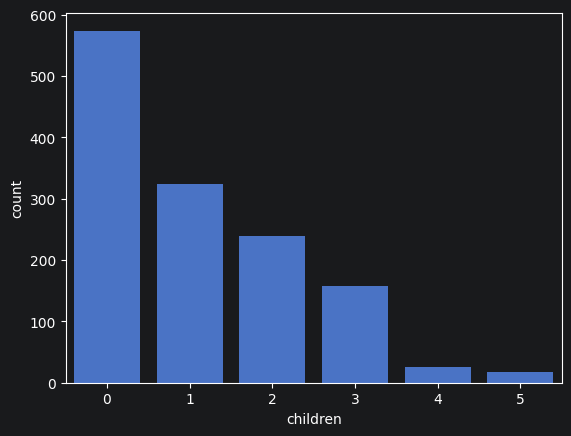

In [11]:
sb.countplot(x = df['children'])

<Axes: xlabel='gender', ylabel='count'>

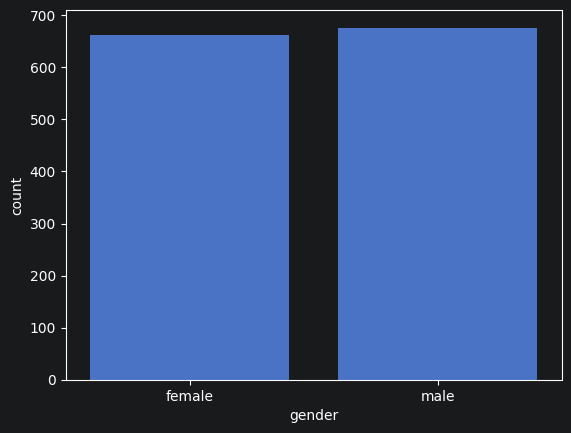

In [12]:
sb.countplot(x = df['gender'])

<Axes: xlabel='smoker', ylabel='count'>

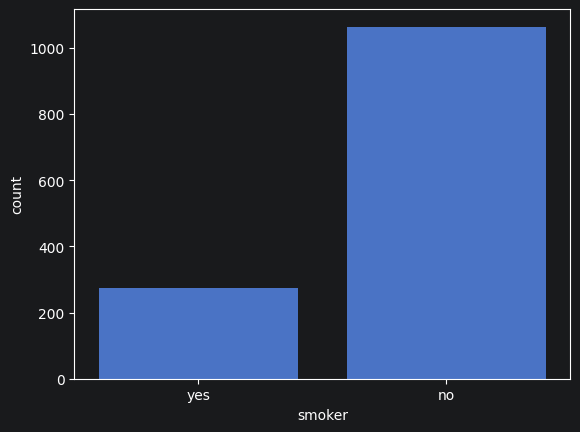

In [13]:
sb.countplot(x = df['smoker'])

<Axes: xlabel='region', ylabel='count'>

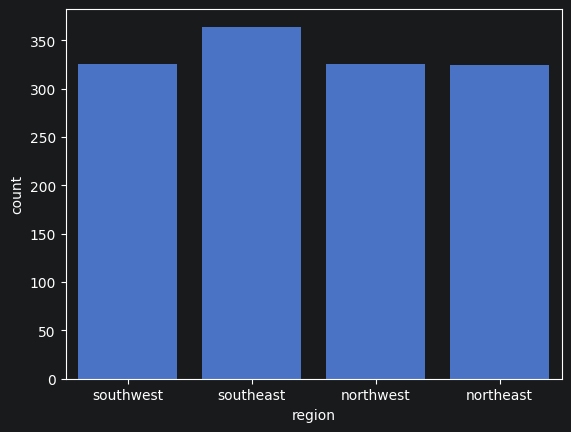

In [14]:
sb.countplot(x = df['region'])

### Box Plotting of Cols

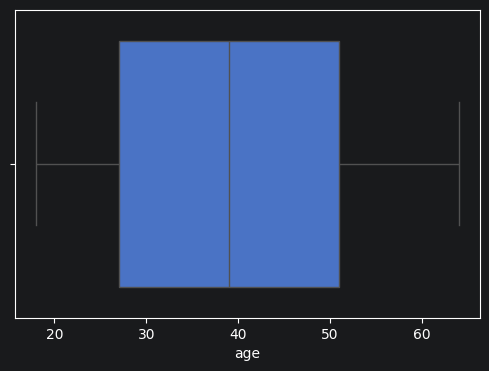

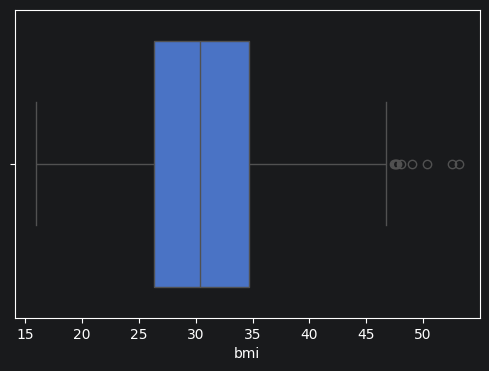

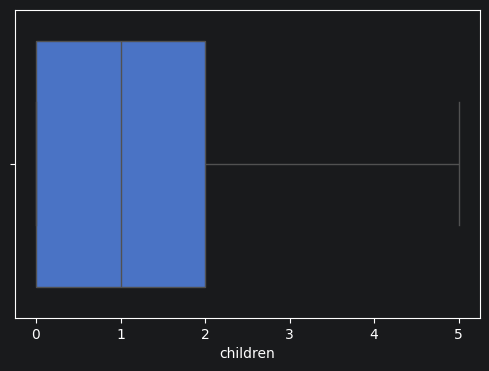

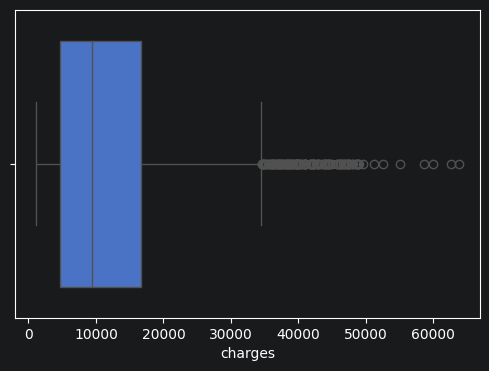

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sb.boxplot(x = df[col])

### Heat map correlation of cols

<Axes: >

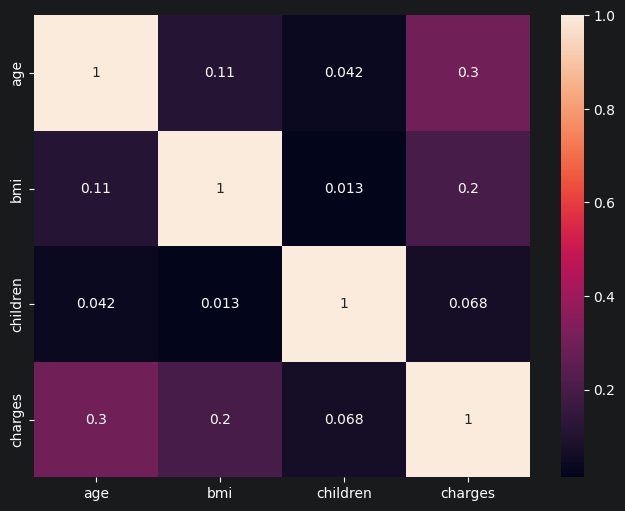

In [16]:
plt.figure(figsize=(8, 6))
sb.heatmap(df.corr(numeric_only=True), annot=True)

## Data Cleaning And Preprocessing

In [17]:
df_cleaned = df.copy()

In [18]:
df_cleaned.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
print(df_cleaned.shape)

(1338, 7)


In [20]:
df_cleaned.drop_duplicates(inplace=True)

In [21]:
print(df_cleaned.shape)

(1337, 7)


#### Find missing value in the DataFrame

In [22]:
df_cleaned.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Checking datatype of cols

In [23]:
df_cleaned.dtypes

age           int64
gender       object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

# Label Encoding

##### Map gender values: female → 1, male → 0


In [24]:
df_cleaned['gender'] = df_cleaned['gender'].map({
    "male": 0,
    "female": 1
})

In [25]:
df_cleaned.head(3)

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.90,0,yes,southwest,16884.9240
1,18,0,33.77,1,no,southeast,1725.5523
2,28,0,33.00,3,no,southeast,4449.4620


##### Map smoker values: yes → 1, no → 0

In [26]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({
    "yes": 1,
    "no": 0
})

In [27]:
df_cleaned.head()

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


##### Rename the gender column to is_female and smoker column to is_smoker for binary representation

In [28]:
df_cleaned.rename(columns={
    "gender" : "is_female",
    "smoker": "is_smoker"
}, inplace=True)

In [29]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


### One hot encoding

In [30]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'])

In [31]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


In [32]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


### Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

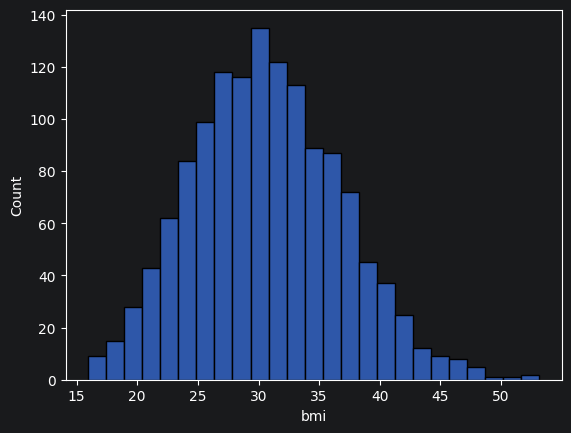

In [33]:
sb.histplot(df_cleaned['bmi'])

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,Obese
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,Obese
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,Obese
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,Overweight


In [36]:
df_cleaned['age_category'] = pd.cut(
    df_cleaned['age'],
    bins=[13, 17, 25, 59, np.inf],
    labels=['Teenager', 'Young Adult', 'Adult', 'Senior Citizen'],
    include_lowest=True
)

In [37]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category,age_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight,Young Adult
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese,Young Adult
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese,Adult
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal,Adult
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,Obese,Adult
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,Obese,Young Adult
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,Obese,Young Adult
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,Overweight,Young Adult


In [38]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'])

In [39]:
df_cleaned.head(8)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,age_category,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Young Adult,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Young Adult,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Adult,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Adult,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Adult,0,0,1,0
5,31,1,25.740,0,0,3756.62160,0,0,1,0,Adult,0,0,1,0
6,46,1,33.440,1,0,8240.58960,0,0,1,0,Adult,0,0,0,1
7,37,1,27.740,3,0,7281.50560,0,1,0,0,Adult,0,0,1,0


### Preprocessing

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])


In [42]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,age_category,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,1,Young Adult,0,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1,0,Young Adult,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1,0,Adult,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,0,Adult,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,0,Adult,0,0,1,0


### pearsonr Correlation Calculation

In [43]:
from scipy.stats import pearsonr

# List of features to check against target(charges)
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight',
    'bmi_category_Obese'
]

correlations = {
    feature : pearsonr(
        df_cleaned[feature],
        df_cleaned['charges']
    )[0]

    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

correlation_df.sort_values(by='Pearson Correlation', ascending=False)


,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298308
1,bmi,0.198401
11,bmi_category_Obese,0.197659
7,region_southeast,0.073578
2,children,0.067389
5,region_northeast,0.005945
6,region_northwest,-0.038695
8,region_southwest,-0.043637
3,is_female,-0.058044


In [44]:
cat_features = [
    'is_female', 'is_smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight',
    'bmi_category_Obese'
]

In [49]:
from scipy.stats import chi2_contingency

In [51]:
alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_results = {}

for col in cat_features:
    contiguous = pd.crosstab(
        df_cleaned[col],
        df_cleaned['charges_bin']
    )

    chi2_stat, p_val, _, _ = chi2_contingency(contiguous)

    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Fail to Reject Null (Drop Feature)'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Create final result table AFTER the loop
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

In [52]:
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Fail to Reject Null (Drop Feature)
region_northeast,6.438442,0.092122,Fail to Reject Null (Drop Feature)
region_southwest,5.091893,0.165191,Fail to Reject Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Fail to Reject Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Fail to Reject Null (Drop Feature)
region_northwest,1.13424,0.768815,Fail to Reject Null (Drop Feature)


In [53]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker']]

final_df

,age,is_female,bmi,children,is_smoker
0,-1.440418,1,-0.453160,-0.909234,1
1,-1.511647,0,0.509422,-0.079442,0
2,-0.799350,0,0.383155,1.580143,0
3,-0.443201,0,-1.305052,-0.909234,0
4,-0.514431,0,-0.292456,-0.909234,0
...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0
1334,-1.511647,1,0.206053,-0.909234,0
1335,-1.511647,1,1.014490,-0.909234,0
1336,-1.297958,1,-0.797524,-0.909234,0
